In [5]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
df = pd.read_csv("./my1995-2014-fuel-consumption-ratings-5-cycle.csv")

In [8]:
df

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,1995,Acura,Integra,Subcompact,1.8,4,A4,X,11.6,8.3,10.1,28,232,NaN,NaN
1,1995,Acura,Integra,Subcompact,1.8,4,M5,X,11.0,8.3,9.8,29,225,NaN,NaN
2,1995,Acura,Integra GS-R,Subcompact,1.8,4,M5,Z,10.8,8.3,9.7,29,223,NaN,NaN
3,1995,Acura,Legend,Compact,3.2,6,A4,Z,14.2,10.5,12.5,23,288,NaN,NaN
4,1995,Acura,Legend Coupe,Compact,3.2,6,A4,Z,14.6,11.0,13.0,22,299,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17848,2014,Volvo,XC60 AWD,Sport utility vehicle: Small,3.0,6,AS6,X,13.4,9.8,11.8,24,271,NaN,NaN
17849,2014,Volvo,XC60 AWD,Sport utility vehicle: Small,3.2,6,AS6,X,13.2,9.5,11.5,25,264,NaN,NaN
17850,2014,Volvo,XC70 AWD,Sport utility vehicle: Small,3.0,6,AS6,X,13.4,9.8,11.8,24,271,NaN,NaN
17851,2014,Volvo,XC70 AWD,Sport utility vehicle: Small,3.2,6,AS6,X,12.9,9.3,11.3,25,260,NaN,NaN


In [10]:
dataset = df.copy()

In [11]:
# verify successful load with some randomly selected records
dataset.sample(5)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
12717,2010,Chevrolet,HHR,Sport utility vehicle,2.2,4,A4,X,11.0,7.8,9.5,30,219,NaN,NaN
1854,1997,GMC,G15/G25 Savana Passenger,Van: Passenger,5.7,8,A4,X,19.6,13.8,17.0,17,391,NaN,NaN
13333,2010,Porsche,Boxster,Two-seater,2.9,6,M6,Z,12.7,8.8,10.9,26,251,NaN,NaN
7718,2005,GMC,Envoy XL,Sport utility vehicle,5.3,8,A4,X,17.6,12.6,15.3,18,352,NaN,NaN
6797,2004,GMC,K1500 Yukon 4X4 FFV,Sport utility vehicle,5.3,8,A4,X,21.5,16.7,19.3,15,444,NaN,NaN


In [12]:
dataset.describe()

,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,0.0,0.0
mean,2005.508262,3.449885,5.948468,14.547393,10.478805,12.716882,23.611270,287.205176,NaN,NaN
std,5.689300,1.326597,1.752572,3.709201,2.662348,3.202425,6.001112,65.637391,NaN,NaN
min,1995.000000,0.800000,2.000000,4.500000,4.000000,4.500000,10.000000,104.000000,NaN,NaN
25%,2001.000000,2.400000,4.000000,12.000000,8.700000,10.600000,19.000000,242.000000,NaN,NaN
50%,2006.000000,3.300000,6.000000,14.000000,9.800000,12.200000,23.000000,278.000000,NaN,NaN
75%,2010.000000,4.300000,8.000000,16.700000,12.100000,14.600000,27.000000,329.000000,NaN,NaN
max,2014.000000,8.400000,16.000000,33.300000,22.100000,27.500000,63.000000,633.000000,NaN,NaN


# Select Features

Select a few features that might be indicative of CO2 emission to explore more.

In [18]:
cdf = dataset[['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']]
cdf.sample(9)

,Engine size (L),Cylinders,Combined (L/100 km),CO2 emissions (g/km)
2114,1.6,4,11.3,260
6516,3.6,6,12.4,285
9863,5.7,8,16.0,368
117,5.7,8,13.7,315
4171,2.8,6,12.7,292
7779,2.2,4,12.0,276
12994,2.0,4,9.1,209
6274,2.0,4,10.3,237
5707,5.7,8,11.7,269


# Visualize features

Consider the histograms for each of these features.

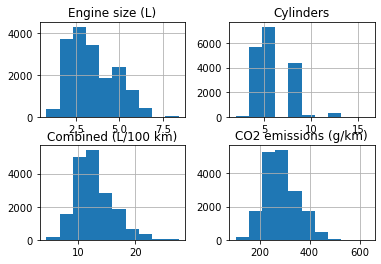

In [19]:
viz = cdf[['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']]
viz.hist()
plt.show()

 As you can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.
Go ahead and display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.

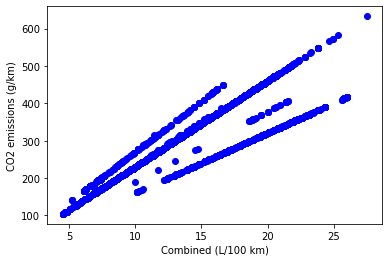

In [21]:
plt.scatter(cdf['Combined (L/100 km)'], cdf['CO2 emissions (g/km)'],  color='blue')
plt.xlabel("Combined (L/100 km)")
plt.ylabel("CO2 emissions (g/km)")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. Their intercepts are similar, while they noticeably differ in their slopes.

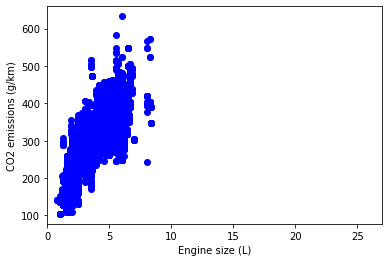

In [22]:
plt.scatter(cdf['Engine size (L)'], cdf['CO2 emissions (g/km)'],  color='blue')
plt.xlabel("Engine size (L)")
plt.ylabel("CO2 emissions (g/km)")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, you can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.

# Plot CYLINDER against CO2 Emission, to see how linear their relationship is.

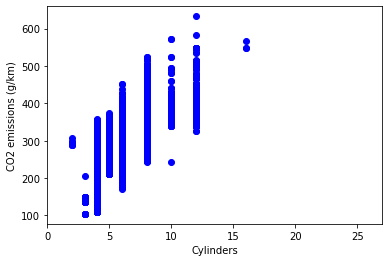

In [23]:
plt.scatter(cdf['Cylinders'], cdf['CO2 emissions (g/km)'],  color='blue')
plt.xlabel("Cylinders")
plt.ylabel("CO2 emissions (g/km)")
plt.xlim(0,27)
plt.show()

# Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, you will use engine size to predict CO2 emission with a linear regression model.
You can begin the process by extracting the input feature and target output variables, X and y, from the dataset.

In [32]:
#X = cdf['Engine size (L)'].to_numpy()
#y = cdf['CO2 emissions (g/km)'].to_numpy()

In [33]:
X = cdf['Combined (L/100 km)'].to_numpy()
y = cdf['CO2 emissions (g/km)'].to_numpy()

# Create train and test datasets
Next, you will split the dataset into mutually exclusive training and testing sets. You will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data.

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, you want to randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller your data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that your evaluation of generalizability will have less reliability. Bigger is better when it comes to data.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.

In [35]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (14282,), (14282,))

# Build a simple linear regression model
You'll use scikit-learn to build your model as follows.

In [36]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  18.95992271236293
Intercept:  46.1278204467429


Here, Coefficient and Intercept are the regression parameters determined by the model.
They define the slope and intercept of the 'best-fit' line to the training data.

# Visualize model outputs
You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.

Text(0, 0.5, 'CO2 emissions (g/km)')

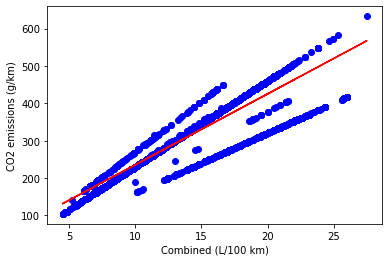

In [37]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Combined (L/100 km)")
plt.ylabel("CO2 emissions (g/km)")

# Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set:

1. Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

2. Mean Squared Error (MSE): MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

3. Root Mean Squared Error (RMSE). RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

4. R2-Score is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 13.74
Mean squared error: 639.63
Root mean squared error: 25.29
R2-score: 0.85


In [42]:
import pickle

# Save the model to a .pkl file
with open('model_fuel_cnsumption.pkl', 'wb') as file:
    pickle.dump(regressor, file)

print("Model saved as .pkl")

# --- To load it back later ---
# with open('model.pkl', 'rb') as file:
#     loaded_model_pkl = pickle.load(file)

Model saved as .pkl
